# Google Play Store — Exploratory Data Analysis

**Showcasing opportunity in the Google Playstore**

**Author:** Reuben Cervantes 

**Dataset:** Google Play Store Apps (10,800 apps, 13 columns)

## Why this project
App stores are winner take all markets, so understanding what separates a
successful app from an ignored one is a real product question.

This notebook covers the foundation loading, inspecting, auditing, cleaning
data, and a chart to revealing where the opportunity lies.

**A note on vintage.** This is a 2018 snapshot of the Play Store, so the findings
describe the market as it was then. The *method* — separating typical demand (median)
from headline demand (average) to find winner-take-all categories — is what transfers;
acting on the specific categories would require current data.

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import duckdb 

# Show all columns and don't cut off wide text when printing tables
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("pandas version:", pd.__version__)

df = pd.read_csv("../Data/google_play_store_dataset.csv")

# .shape returns (rows, columns)
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
# display helper for the notebook
def money_m(v):
    """Format an install count in millions: 16577038.0 -> '16.58M'."""
    return f"{v / 1e6:.2f}M"

pandas version: 3.0.3
Rows: 10,841   Columns: 13


## First look at the data

Before trusting anything, we eyeball the table and its structure:
- `df.head()` — the first 5 rows, so we see what real values look like
- `df.info()` — every column, its non-null count, and its **data type** (`dtype`)
- `df.describe()` — summary statistics for numeric columns

Watch the `dtype` column in `.info()` — that's where the first problems hide.

In [268]:
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [269]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [270]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## Data-quality audit

`isnull().sum()` counts blanks per column. `Rating` is missing for many apps
(ones nobody has rated yet).

In [271]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

## Duplicate rows
The dataset was scraped, so the same app can appear multiple times.
`duplicated()` flags exact repeat rows; summing gives the count.

In [272]:
print("Exact duplicate rows:", df.duplicated().sum())

# Duplicate app names are even more common (same app, slightly different scrape)
print("Duplicate app names:", df["App"].duplicated().sum())

Exact duplicate rows: 483
Duplicate app names: 1181


## The corrupted row
Ratings are on a 1–5 scale, so any rating above 5 is impossible. Filtering for
`Rating > 5` surfaces one row where a missing `Category` shifted every field one
column to the left. The value now sitting in `Rating` is 19 — really the app's
review count and because that exceeds the 1–5 scale, the `Rating > 5` filter
catches the row.

In [273]:
# to_numeric(..., errors="coerce") turns non-numbers into NaN so the compare is safe
bad_rating = df[pd.to_numeric(df["Rating"], errors="coerce") > 5]
bad_rating

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [274]:
for col in ["Installs", "Price", "Reviews", "Size"]:
    print(f"{col:10s} sample -> {df[col].unique()[:5]}")

Installs   sample -> <StringArray>
['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+']
Length: 5, dtype: str
Price      sample -> <StringArray>
['0', '$4.99', '$3.99', '$6.99', '$1.49']
Length: 5, dtype: str
Reviews    sample -> <StringArray>
['159', '967', '87510', '215644', '167']
Length: 5, dtype: str
Size       sample -> <StringArray>
['19M', '14M', '8.7M', '25M', '2.8M']
Length: 5, dtype: str


## Clean the data

Make a copy so original data stays the same.

In [275]:
clean = df.copy()
start_rows = len(clean)


### Drop the corrupted row
It's a single bad record, so removing it is the honest fix. `.drop()` removes it
by its index label.

In [276]:
corrupt_index = df[pd.to_numeric(df["Rating"], errors="coerce") > 5].index
clean = clean.drop(index=corrupt_index)
print("Dropped", len(corrupt_index), "corrupted row(s)")  # Only 1 row in this dataset

Dropped 1 corrupted row(s)


### Remove duplicates


In [277]:
clean = clean.drop_duplicates()
print("Rows after exact de-dup:", len(clean))   # 10,357 


Rows after exact de-dup: 10357


### Convert
`Installs`, `Price`, and `Reviews` were scraped as text with symbols
(`"10,000+"`, `"$4.99"`).

In [278]:
# Installs: "10,000+" -> 10000
clean["Installs"] = (clean["Installs"].astype(str)
                       .str.replace(",", "", regex=False)
                       .str.replace("+", "", regex=False)
                       .astype(int))

# Price: "$4.99" -> 4.99 ; "0" stays 0.0
clean["Price"] = (clean["Price"].astype(str)
                    .str.replace("$", "", regex=False)
                    .astype(float))

# Reviews came in as text too
clean["Reviews"] = clean["Reviews"].astype(int)

# Rebuild Type from Price so the two can never contradict each other
clean["Type"] = np.where(clean["Price"] > 0, "Paid", "Free")

### One more integrity check: reviews can't exceed installs
A review requires an install, so `Reviews > Installs` is impossible. 

In [279]:
# Sanity check: an app can't have more reviews than installs.
# (Only valid now that both columns are real integers.)
impossible = clean[clean["Reviews"] > clean["Installs"]]
print("Rows where Reviews > Installs (impossible):", len(impossible))
impossible[["App", "Reviews", "Installs"]].head()

Rows where Reviews > Installs (impossible): 11


,App,Reviews,Installs
2454,KBA-EZ Health Guide,4,1
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,4,1
4663,Alarmy (Sleep If U Can) - Pro,10249,10000
5812,AX Watch for WatchMaker,2,1
5917,Ra Ga Ba,2,1


### Decision keep these 11 rows

`Installs` is a lower bound: an app shown as `10,000` is really somewhere in
`[10,000, 50,000)`, so Alarmy's 10,249 reviews are consistent, not corrupt. The
same holds at the bottom, an app shown as `1` is in the `1+` bucket (1–4 true
installs).

### De-duplicate app names

Same app name appears more than once with different review counts. Sorted by reviews descending before dropping duplicates
so keep='first' keeps the most current record of each app name rather than an arbitrary one.

In [280]:
clean = (clean.sort_values(
             ["Reviews", "Installs", "App"],          # explicit, total ordering
             ascending=[False, False, True],
             kind="stable")                            # reproducible tie-breaking
         .drop_duplicates(subset="App", keep="first"))
print("Rows after app-name de-dup:", len(clean))       # 9,659

Rows after app-name de-dup: 9659


### Cleaning summary
A quick before and after so anyone reading can see exactly what was removed and trust
the table that follows. Keep the missing `Rating` values rather than imputing
them — filling 1,400+ blanks with the mean would fabricate quality signal what
does not actually have and simply exclude them where a rating is required.

In [281]:
print(f"Started with {start_rows:,} rows")
print(f"Ended with   {len(clean):,} rows")
print(f"Removed      {start_rows - len(clean):,} rows "
      f"({(start_rows - len(clean)) / start_rows:.1%})")

Started with 10,841 rows
Ended with   9,659 rows
Removed      1,182 rows (10.9%)


## Question 1 — Where's the market opportunity?

A team deciding what kind of app to build wants categories with **high demand but
low competition**. We measure each category on two axes:

- **Demand** — measured two ways: the **average** installs per app (total pull of the
  category) and the **median** installs per app (what a *typical* app actually achieves).
  When average ≫ median, demand isn't broad — it's concentrated in a few giant apps, and
  the category is winner-take-all rather than open.
- **Competition** — how many apps already exist in that category

Categories with high demand and few competitors are the opening; categories
crammed with apps that each capture little are already saturated.

To show SQL alongside pandas, we run this aggregation in **DuckDB**, which queries
the DataFrame directly.

### A note on the `Installs` column
Google reports installs in coarse buckets (`10,000+`, `100,000+`, `1,000,000+`),
so every value is a lower bound, not an exact count. Averages and medians of
these buckets are still meaningful as order of magnitude signals, and the tables
below are shown rounded to reflect that. It also explains why several categories
share an identical median of exactly 1,000,000 — that's a bucket boundary, not a
precise measurement.

### Reading the table
Ranking by **median** installs not the average changes the story. Categories like
**Video Players, Shopping, Entertainment, Education and Weather** have a healthy
median.


In [282]:
cat = duckdb.query("""
    SELECT Category,
           COUNT(*)                AS num_apps,        -- competition
           ROUND(AVG(Installs))    AS avg_installs,    -- total pull
           ROUND(MEDIAN(Installs)) AS median_installs, -- what a typical app gets
           ROUND(AVG(Installs) / NULLIF(MEDIAN(Installs), 0), 1) AS concentration,
           ROUND(AVG(Rating), 2)   AS avg_rating       -- typical quality
    FROM clean
    GROUP BY Category
    ORDER BY median_installs DESC
""").to_df()

(cat.head(10).style
    .format({"avg_installs": money_m, "median_installs": money_m}))

,Category,num_apps,avg_installs,median_installs,concentration,avg_rating
0,EDUCATION,107,1.78M,1.00M,1.800000,4.350000
1,SHOPPING,202,6.93M,1.00M,6.900000,4.230000
2,ENTERTAINMENT,87,11.38M,1.00M,11.400000,4.130000
3,GAME,946,14.23M,1.00M,14.200000,4.240000
4,WEATHER,79,4.57M,1.00M,4.600000,4.240000
5,VIDEO_PLAYERS,164,23.98M,1.00M,24.000000,4.040000
6,PHOTOGRAPHY,281,16.58M,1.00M,16.600000,4.160000
7,HOUSE_AND_HOME,73,1.33M,0.50M,2.700000,4.140000
8,FOOD_AND_DRINK,112,1.89M,0.30M,6.300000,4.170000
9,TRAVEL_AND_LOCAL,219,13.22M,0.10M,132.200000,4.070000


### The saturated end
Sorting the same table by number of apps surfaces the crowded categories — the
flip side of the opportunity map.


In [283]:
# The saturation warning: most-crowded categories, fewest installs each
(cat.sort_values("num_apps", ascending=False).head(5).style
    .format({"avg_installs": money_m, "median_installs": money_m}))

,Category,num_apps,avg_installs,median_installs,concentration,avg_rating
22,FAMILY,1874,3.32M,0.05M,66.400000,4.180000
3,GAME,946,14.23M,1.00M,14.200000,4.240000
20,TOOLS,829,9.77M,0.05M,195.500000,4.040000
30,BUSINESS,420,1.66M,0.00M,1659.900000,4.100000
31,MEDICAL,395,0.10M,0.00M,96.900000,4.170000


### Scoring the quadrants in SQL
The scatter *shows* the quadrants; this query defines them. Using window
functions, we rank each category on demand and (inverse) competition, average the
two into an opportunity score, and label each category by which quadrant it falls
in so the chart can color by a real column instead of us eyeballing corners.

In [284]:
cat_ranked = duckdb.query("""
    SELECT
        Category, num_apps, avg_installs, median_installs, concentration, avg_rating,

        -- opportunity = high TYPICAL demand AND low competition, each ranked 0–1 then averaged
        ROUND(( PERCENT_RANK() OVER (ORDER BY median_installs)
              + PERCENT_RANK() OVER (ORDER BY num_apps DESC) ) / 2, 2) AS opportunity,

        -- label each category by its position relative to the medians
        CASE
            WHEN median_installs >= MEDIAN(median_installs) OVER ()
             AND num_apps        <  MEDIAN(num_apps)        OVER () THEN 'Opportunity'
            WHEN median_installs <  MEDIAN(median_installs) OVER ()
             AND num_apps        >= MEDIAN(num_apps)        OVER () THEN 'Saturated'
            ELSE 'Mixed'
        END AS quadrant
    FROM cat
    ORDER BY opportunity DESC
""").to_df()


(cat_ranked.head(10).style
    .format({"avg_installs": money_m, "median_installs": money_m}))

,Category,num_apps,avg_installs,median_installs,concentration,avg_rating,opportunity,quadrant
0,HOUSE_AND_HOME,73,1.33M,0.50M,2.700000,4.140000,0.810000,Opportunity
1,WEATHER,79,4.57M,1.00M,4.600000,4.240000,0.810000,Opportunity
2,ENTERTAINMENT,87,11.38M,1.00M,11.400000,4.130000,0.770000,Opportunity
3,EDUCATION,107,1.78M,1.00M,1.800000,4.350000,0.750000,Opportunity
4,FOOD_AND_DRINK,112,1.89M,0.30M,6.300000,4.170000,0.700000,Opportunity
5,VIDEO_PLAYERS,164,23.98M,1.00M,24.000000,4.040000,0.700000,Opportunity
6,COMICS,56,0.80M,0.10M,8.000000,4.180000,0.690000,Opportunity
7,PARENTING,60,0.53M,0.10M,5.300000,4.300000,0.670000,Opportunity
8,SHOPPING,202,6.93M,1.00M,6.900000,4.230000,0.670000,Opportunity
9,ART_AND_DESIGN,61,1.86M,0.10M,18.600000,4.360000,0.660000,Opportunity


## Chart - Opportunity Map
One scatter plot puts both axes together: competition on the x-axis, demand on the
y-axis, one bubble per category. Read it by quadrant — **top-left** (high demand,
few apps) is the opening; **bottom-right** (many apps, low demand each) is
saturated.

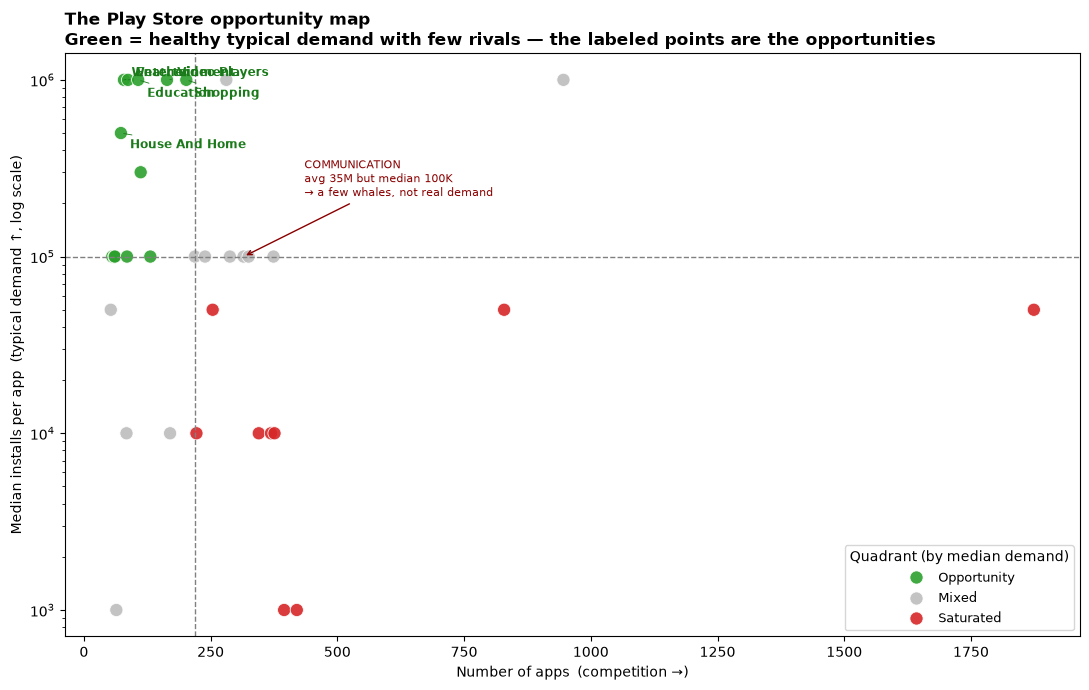

In [285]:
fig, ax = plt.subplots(figsize=(11, 7))

palette = {"Opportunity": "#2ca02c", "Saturated": "#d62728", "Mixed": "#bdbdbd"}
sns.scatterplot(data=cat_ranked, x="num_apps", y="median_installs",
                hue="quadrant", palette=palette,
                s=90, edgecolor="white", linewidth=0.6, alpha=0.9, ax=ax)
ax.set_yscale("log")
ax.axvline(cat_ranked["num_apps"].median(),     color="gray", ls="--", lw=1)
ax.axhline(cat_ranked["median_installs"].median(), color="gray", ls="--", lw=1)

# label ONLY the recommended opportunities; (dx, dy%) hand-set so labels never overlap
highlight = {"VIDEO_PLAYERS": (20, 10), "ENTERTAINMENT": (15, 10), "SHOPPING": (15, -16),
             "WEATHER": (15, 10), "EDUCATION": (18, -16), "HOUSE_AND_HOME": (18, -14)}
for name, (dx, dy) in highlight.items():
    r = cat_ranked[cat_ranked["Category"] == name].iloc[0]
    ax.annotate(name.replace("_", " ").title(),
                        xy=(r["num_apps"], r["median_installs"]),
        xytext=(r["num_apps"] + dx, r["median_installs"] * (1 + dy / 100)),
                fontsize=8.5, color="#1a7a1a", fontweight="bold", va="center",
                arrowprops=dict(arrowstyle="-", color="#1a7a1a", lw=0.6))

# the one callout that carries the whole insight
comm = cat_ranked[cat_ranked["Category"] == "COMMUNICATION"].iloc[0]
ax.annotate("COMMUNICATION\navg 35M but median 100K\n→ a few whales, not real demand",
                    xy=(comm["num_apps"], comm["median_installs"]),
        xytext=(comm["num_apps"] + 120, comm["median_installs"] * 2.2),
            fontsize=8, color="#8a0000",
            arrowprops=dict(arrowstyle="->", color="#8a0000", lw=1))

ax.set_title("The Play Store opportunity map\n"
             "Green = healthy typical demand with few rivals — the labeled points are the opportunities",
             fontsize=12, fontweight="bold", loc="left")
ax.set_xlabel("Number of apps  (competition →)")
ax.set_ylabel("Median installs per app  (typical demand ↑, log scale)")
ax.legend(fontsize=9, loc="lower right", title="Quadrant (by median demand)")
plt.tight_layout()
plt.show()

### What the map shows
Two stories, and the median is what separates them. **Communication, Social, and Tools**
sit high on **average** installs but collapse on the median (100K, 100K, 50K) — their pull is
a handful of billion-install giants, not demand a new app can tap. The green corner is the
real opening: **Weather, Entertainment, Video Players, Shopping, and Education** combine a
healthy typical install count with relatively few competitors.

At the opposite extreme, **Family** is the saturation warning: **1,874 apps** — the most of
any category — yet a median of only 50K installs. A newcomer there fights the most rivals
for the smallest payoff.

### How to read this — and how not to
This map shows where *typical* demand is high **relative to** competition. It does
**not** prove a new entrant could capture that demand. Low app counts in **Weather** or
**Education** may reflect a mature, well-served niche rather than an open field, and a
high median may signal strong incumbents rather than room to grow. So treat these
categories as **hypotheses to validate, not recommendations**. 